# Mesh resolution

In [ ]:
from lucifex.solver import OptionsPETSc
from lucifex.fdm import AB, CN
from lucifex.sim import parallel_run, as_grid_simulation
from lucifex.viz import plot_colormap, plot_line, set_ipynb_variable
from lucifex.utils.array_utils import as_index
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE

STORE = 1
create_sim = dns_system_a(store_delta=STORE)

Nx_opts = (60, 120, 120, 160, 160, 180)
Ny_opts = (60, 60, 120, 120, 160, 180)
CELL_TYPE = 'quadrilateral'
COURANT_ADV = 0.75
COURANT_DIFF = 0.75
COURANT_REAC = 0.1

n_proc = set_ipynb_variable('N_PROC', 3)
n_stop = set_ipynb_variable('N_STOP', 300)
t_stop = 20.0
dt_init = 1e-6
n_init = 10

simulations = parallel_run(
    create_sim, n_proc, n_stop, 
    dt_init=dt_init, n_init=n_init,
    serialize=as_grid_simulation, link=True,
)(
    cell=CELL_TYPE,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    D_adv=AB(1)@CN,
    D_diff=AB(1)@CN,
    courant_adv=COURANT_ADV,
    courant_diff=COURANT_DIFF,
    courant_reac=COURANT_REAC,
    c_stabilization=None,
    c_limits=None,
    c_petsc=OptionsPETSc('gmres', 'ilu'),
    flow_petsc=(OptionsPETSc('cg', 'hypre'), None),
    diagnostic=True,
)(
    Nx=Nx_opts,
    Ny=Ny_opts,
)

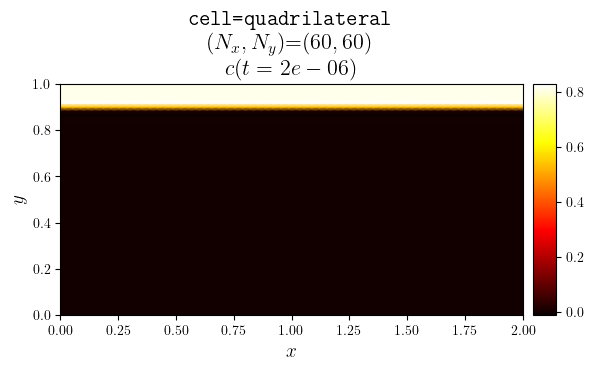

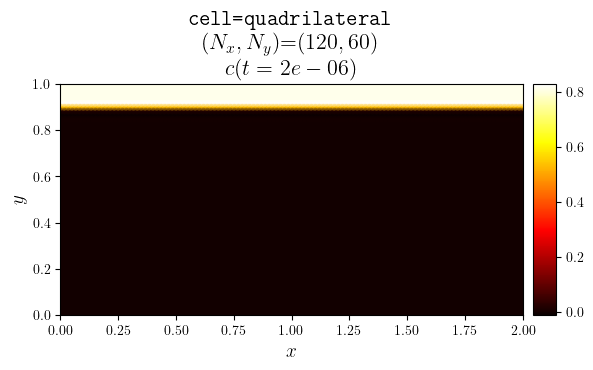

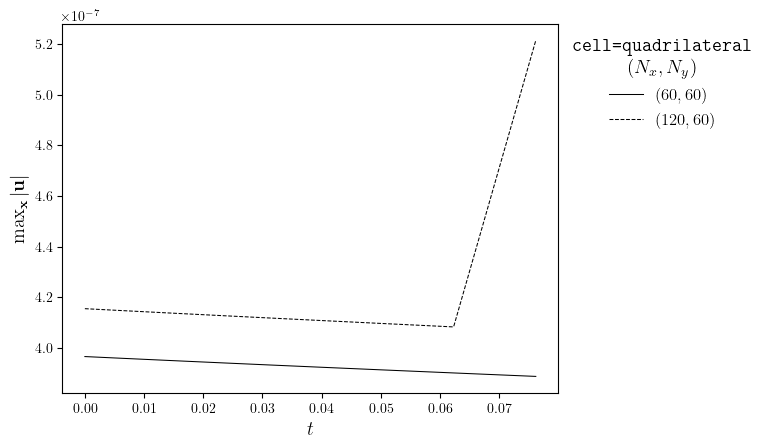

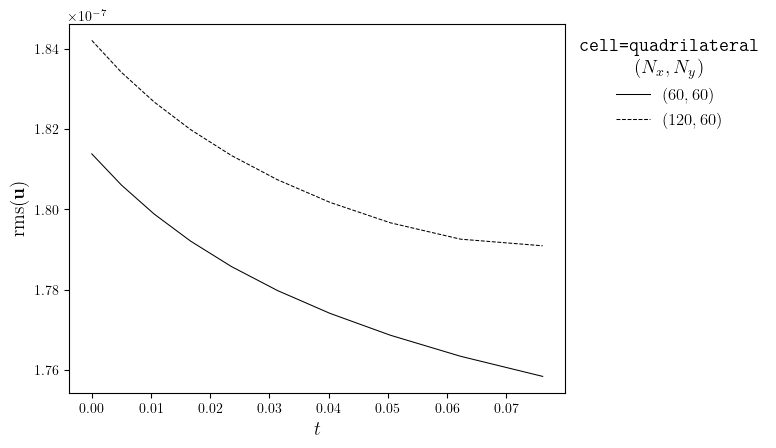

In [6]:
t_target = 2e-6

uMax_lines, uRMS_lines, labels = [], [], []
legend_title = f'$\\texttt{{cell={CELL_TYPE}}}$\n $(N_x, N_y)$'

for (Nx, Ny), sim in simulations.items():
    label = f'$({Nx}, {Ny})$'
    labels.append(label)
    uMinMax = sim['uMinMax']
    uMax = uMinMax.sub(1)
    uMax_lines.append((uMax.time_series, uMax.value_series))
    uRMS = sim['uRMS']
    uRMS_lines.append((uRMS.time_series, uRMS.value_series))
    c = sim['c']
    time_index = as_index(c.time_series, t_target)
    cmap_title = f'{legend_title}$=${label}\n$c(t={c.time_series[time_index]})$'
    fig, ax = plot_colormap(c.series[-1], title=cmap_title)

fig, ax = plot_line(
    uMax_lines,
    x_label='$t$',
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
    legend_labels=labels,
    legend_title=legend_title,
)
fig, ax = plot_line(
    uRMS_lines,
    x_label='$t$',
    y_label='$\mathrm{rms}(\mathbf{u})$',
    legend_labels=labels,
    legend_title=legend_title,
)